# Data analysis and processing of real squeezing data

We're going to re-analyse the data from the paper [Compact, low-threshold squeezed light source](https://opg.optica.org/abstract.cfm?uri=oe-27-26-37877), as well as data taken during the project that led to the paper [Distributed quantum sensing in a continuous-variable entangled network](https://www.nature.com/articles/s41567-019-0743-x).

Both of these papers are about [squeezed light](https://wikipedia.org/en/Squeezed_states_of_light) generated by an [optical parametric oscillator (OPO)](https://wikipedia.org/en/Optical_parametric_oscillator). In the textbook description of squeezed vacuum, the variance of the squeezed quadrature (let's say it's $\hat x$) is $\text{Var}(x) = e^{-2r}$ and for the anti-squeezed quadrature ($\hat p$) it is $\text{Var}(p) = e^{2r}$. Here, $r$ is the _squeezing parameter_. For a realistic state, the situation is more complex: $r$ is not well-defined in the experiment, but the variance will instead depend on losses, the frequency that it is observed at, etc. Below, I go through a theoretical model that includes these effects. This model is _heavily_ used in the QPIT labs at DTU Physics.

### Squeezing model

Denoting by $V_+$ the variance of the anti-squeezing relative to shotnoise (the standard noise level, whose value depends on the definition of the quadrature operators), and by $V_-$ the squeezing variance, the simplest formula for the squeezing of an OPO is for the case of no losses and at DC (i.e. frequency = zero):

$V_\pm = 1 \pm \frac{4\chi}{(1\mp \chi)^2},$

where $\chi=\sqrt{P/P_{th}}$ is the _pump parameter_ given by the power $P$ of the field used for pumping the nonlinear interaction inside the OPO relative to a _threshold power_ $P_{th}$.

For non-zero losses, we have the _overall efficiency_ $\eta = 1-\text{losses}$, and we also introduce the _OPO half-width-half-max bandwidth_ $f_{HWHM}$ (a physical parameter of the cavity) and the frequency of observation $f$ (a parameter of the chosen measurement). Then the expression above becomes

$V_\pm = 1 \pm \frac{4\chi\eta}{(1\mp \chi)^2 + (f/f_{HWHM})^2}.$

Squeezed light is often characterised by [homodyne measurement](https://en.wikipedia.org/wiki/Homodyne_detection), i.e. a measurement of the general quadrature $x_\theta = x\cos\theta + p\sin\theta$. This is done by mixing the quantum signal on a 50:50 beamsplitter with a strong, phase-coherent beam called the local oscillator (LO). The relative phase between the signal and the LO gives $\theta$.

The variance of $x_\theta$ can be obtained by

$V(\theta) = V_-\cos^2\theta + V_+\sin^2\theta$.

Finally, if there is some fluctuation in the observed phase, this can be incorporated by modeling it as a normal distribution around the phase set point with standard deviation $\sigma$ (in units of radians), resulting in a variance

$V(\theta) = \frac{1}{2} V_- (1+\cos(2\theta)e^{-2\sigma^2}) + \frac{1}{2} V_+ (1-\cos(2\theta)e^{-2\sigma^2}) .$

Note that this reduces to the previous expression for $\sigma = 0$.

The amount of squeezing is often presented in relative dB (decibel) units: A relative noise variance of $V_-$ is given in dB by $V_-[\text{dB}] = 10\log_{10}(V_-)$, with the inverse relationship $V_- = 10^{V_-[\text{dB}]/10}$, and the equivalent for the anti-squeezing $V_+$.

### Data loading and processing

The data for the first paper (the "Jens" paper) has been acquired by a Keysight N9000A signal analyzer. It is in CSV format which is easy to import e.g. with NumPy's `genfromtxt` function.

The data for the second paper (the "Xueshi" paper) has been acquired by a LeCroy HDO6034 oscilloscope. This is in a proprietary binary format, so here we need some custom code to import it.

A better way to store large amounts of data is in the commonly used [HDF5 binary data format](https://omni.wikiwand.com/en/articles/Hierarchical_Data_Format). In Python, this can be used via the [h5py](https://www.h5py.org) package.

We will also look at processing the data. For calculating spectra, filtering time series, etc., we will use tools from `scipy.signal` and `scipy.fft`. For fitting data to theoretical models, we will use tools from `scipy.optimize`.

Both datasets are available from [this Dropbox link](https://www.dropbox.com/scl/fo/1dxu97vp9f7vioe9atj7g/AOiqbbVhRn-iOqWwHyzwkZQ?rlkey=qpuxehyvenzmyl7747byxnu15&dl=0). Go download them and place them in a folder `squeezing_data` next to this notebook. If you're in a git repository, make sure to add the name of that folder to your `.gitignore` file! Otherwise you'll be sending 650 MB of data to Github.

In [2]:
!uv pip install git+https://github.com/neago/lecroy-reader.git

Resolved 2 packages in 3.38s                                         5d3f53257⠴ Resolving dependencies...                                                     
Prepared 1 package in 168ms                                              it@5071b3⠙ Preparing packages... (0/1)                                                   
Installed 1 package in 1msfrom git+https://github.com/neago/
 + lecroyreader==0.1 (from git+https://github.com/neago/lecroy-reader.git@5071b31cb0f324b5d3f53257cc1979c008c064eb)


In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import lecroyreader as lecroy
import h5py
import os
from scipy.signal import periodogram, welch
from scipy.fft import rfft, irfft, rfftfreq
from scipy.optimize import curve_fit, least_squares
import re

In [7]:
jens_folder = '/Users/my/Documents/GitHub/sciqis-work/jens'  # replace with correct relative path to the downloaded data
jens_files = os.listdir(jens_folder)
xueshi_folder = '/Users/my/Documents/GitHub/sciqis-work/xueshi'  # replace with correct relative path to the downloaded data
xueshi_files = os.listdir(xueshi_folder)

In [8]:
def lin2db(lin):
    return 10 * np.log10(lin)

def db2lin(db):
    return 10**(db/10)

In [9]:
Vsq = lambda x, eta, frel: 1 - 4*eta*x / ((1+x)**2 + frel**2)
Vasq = lambda x, eta, frel: 1 + 4*eta*x / ((1-x)**2 + frel**2)
Vrot = lambda x, eta, frel, theta: np.cos(theta*np.pi/180)**2 * Vsq(x, eta, frel) + np.sin(theta*np.pi/180)**2 * Vasq(x, eta, frel)

def Vrotfluct(x, eta, frel, theta, sigma_x=0, sigma_p=None):
    if sigma_p is None:
        sigma_p = sigma_x
        
    Vx = .5 * Vsq(x, eta, frel) * (1 + np.cos(2 * theta * np.pi/180) * np.exp(-2 * (sigma_x * np.pi/180)**2))
    Vp = .5 * Vasq(x, eta, frel) * (1 - np.cos(2 * theta * np.pi/180) * np.exp(-2 * (sigma_p * np.pi/180)**2))

    return Vx + Vp

## Jens data

Jens' data folder contains two data sets:

**SPEC**: spectra from $f$ = 1 to 120 MHz recorded at 3 different pump powers $P$.

**5MHz**: observation frequency $f$ fixed at 5 MHz (with a resolution bandwidth of 300 kHz) and measured for 200 ms.

For both series, the number in the filename indicates the optical power in mW, and_A/S_ indicates (anti-)squeezing. _vac_ is a recording of the equivalent signal when the squeezed light is blocked, i.e. the vacuum state. _elec_ is the electronic noise from the detector when also the LO beam is blocked.

The two PNG images in the folder show the already analysed data from these two series.

In [10]:
jens_files

['spectra.png',
 'SPEC_vac.csv',
 '5MHz_2.9_S.csv',
 'SPEC_elec.csv',
 '5MHz_2.9_A.csv',
 '5MHz_elec.csv',
 '5MHz_1.9_S.csv',
 '5MHz_4.3_A.csv',
 '5MHz_4.7_S.csv',
 '5MHz_4.3_S.csv',
 '5MHz_4.7_A.csv',
 '5MHz_1.9_A.csv',
 'power_scaling.png',
 '5MHz_1.1_S.csv',
 'SPEC_2.5_A.csv',
 '5MHz_2.4_A.csv',
 '5MHz_0.5_S.csv',
 '5MHz_3.4_S.csv',
 '5MHz_3.6_S.csv',
 '5MHz_3.6_A.csv',
 '5MHz_vac.csv',
 'SPEC_2.5_S.csv',
 '5MHz_1.1_A.csv',
 '5MHz_2.4_S.csv',
 '5MHz_0.5_A.csv',
 '5MHz_3.4_A.csv',
 '.ipynb_checkpoints',
 'SPEC_1.3_S.csv',
 'SPEC_3.4_S.csv',
 '5MHz_1.4_A.csv',
 'SPEC_3.4_A.csv',
 '5MHz_1.4_S.csv',
 'SPEC_1.3_A.csv']

We select the files containing the spectrum:

In [11]:
sq_spec_files = [os.path.join(jens_folder, f) for f in sorted(jens_files) if 'SPEC' in f and '_S' in f]
asq_spec_files = [os.path.join(jens_folder, f) for f in sorted(jens_files) if 'SPEC' in f and '_A' in f]
elec_spec_file = os.path.join(jens_folder, 'SPEC_elec.csv')
vac_spec_file = os.path.join(jens_folder, 'SPEC_vac.csv')
sq_spec_files, asq_spec_files

(['/Users/my/Documents/GitHub/sciqis-work/jens/SPEC_1.3_S.csv',
  '/Users/my/Documents/GitHub/sciqis-work/jens/SPEC_2.5_S.csv',
  '/Users/my/Documents/GitHub/sciqis-work/jens/SPEC_3.4_S.csv'],
 ['/Users/my/Documents/GitHub/sciqis-work/jens/SPEC_1.3_A.csv',
  '/Users/my/Documents/GitHub/sciqis-work/jens/SPEC_2.5_A.csv',
  '/Users/my/Documents/GitHub/sciqis-work/jens/SPEC_3.4_A.csv'])

In [14]:
spec_powers = [float(os.path.basename(fn).split('_')[1]) for fn in sq_spec_files]
spec_powers

[1.3, 2.5, 3.4]

Read data from the files. The first 45 lines of each file containt metadata, so we first look at these, but then skip them when reading the actual data.

In [15]:
with open(elec_spec_file) as f:
    meta = [f.readline().strip().split(',') for i in range(45)]
for text in meta:
    if len(text) > 1:
        print(f'{text[0]:<25} : {text[1]}')
    else:
        print(text)

['Trace']
['Swept SA']
A.18.12                   : N9000A
503                       : 01
Segment                   : 0
Number of Points          : 5000
Sweep Time                : 0.889488733333
Start Frequency           : 1000000
Stop Frequency            : 120000000
Average Count             : 0
Average Type              : LogPower(Video)
RBW                       : 1100000
RBW Filter                : Gaussian
RBW Filter BW             : 3dB
VBW                       : 300
Sweep Type                : Swept
X Axis Scale              : Lin
PreAmp State              : Off
PreAmp Band               : Low
Trigger Source            : Free
Trigger Level             : 1.2
Trigger Slope             : Positive
Trigger Delay             : 0
Phase Noise Optimization  : Fast
Swept If Gain             : Low
FFT If Gain               : Autorange
RF Coupling               : AC
FFT Width                 : 411900
Ext Ref                   : 10000000
Input                     : RF
RF Calibrator        

In [16]:
electronic = np.genfromtxt(elec_spec_file, delimiter=',', skip_header=45)
vacuum = np.genfromtxt(vac_spec_file, delimiter=',', skip_header=45)
squeezing = np.array([np.genfromtxt(f, delimiter=',', skip_header=45) for f in sq_spec_files])
antisqueezing = np.array([np.genfromtxt(f, delimiter=',', skip_header=45) for f in asq_spec_files])

In [17]:
electronic

array([[ 1.00000000e+06, -9.04096875e+00],
       [ 1.02380476e+06, -9.52563102e+00],
       [ 1.04760952e+06, -1.00301818e+01],
       ...,
       [ 1.19952390e+08, -7.15093108e+01],
       [ 1.19976195e+08, -7.14987887e+01],
       [ 1.20000000e+08, -7.15159757e+01]], shape=(5000, 2))

In [18]:
electronic.shape, vacuum.shape, squeezing.shape, antisqueezing.shape

((5000, 2), (5000, 2), (3, 5000, 2), (3, 5000, 2))

In [19]:
f = electronic[:,0] / 1e6  # first column is frequency (common for all traces) - convert to MHz
electronic = electronic[:,1]
vacuum = vacuum[:,1]
squeezing = squeezing[:,:,1]
antisqueezing = antisqueezing[:,:,1]

As we saw from the "Y Axis Units" in the meta data, the spectrum is already given on a logarithmic scale. We also see this when plotting:

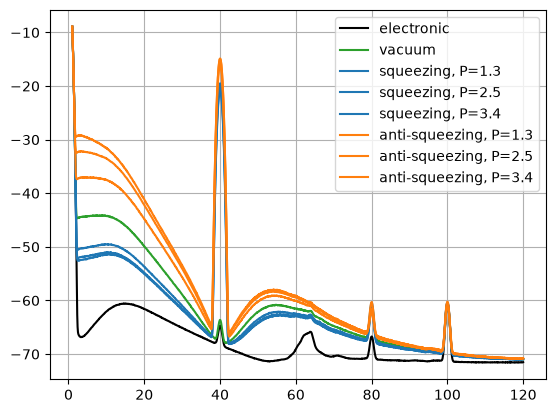

In [20]:
plt.plot(f, electronic, c='k', label='electronic')
plt.plot(f, vacuum, c='C2', label='vacuum')
for power, sq in zip(spec_powers, squeezing):
    plt.plot(f, sq, c='C0', label=f'squeezing, P={power}')
for power, asq in zip(spec_powers, antisqueezing):
    plt.plot(f, asq, c='C1', label=f'anti-squeezing, P={power}')
plt.grid()
plt.legend()

The large peaks at 40 MHz and 100 MHz come from modulations used to lock relative phases in the experiment. These are not relevant for the analysis of the quantum properties of the light.

We are interested in the squeezing and antisqueezing noise variance _relative_ to the vacuum noise, so we normalise to this.
Before doing this, we can subtract the electronic noise which is common for all traces. When performing arithmetics on the spectra, we must first convert from logarithmic to linear scale:

In [21]:
vacuum_corr_lin = db2lin(vacuum) - db2lin(electronic)
squeezing_norm = lin2db((db2lin(squeezing) - db2lin(electronic)) / vacuum_corr_lin)
antisqueezing_norm = lin2db((db2lin(antisqueezing) - db2lin(electronic)) / vacuum_corr_lin)

/var/folders/ww/xl4lr53d2jgdnllssx2fcdth0000gn/T/ipykernel_9798/2130157308.py:2: RuntimeWarning: invalid value encountered in log10
  return 10 * np.log10(lin)


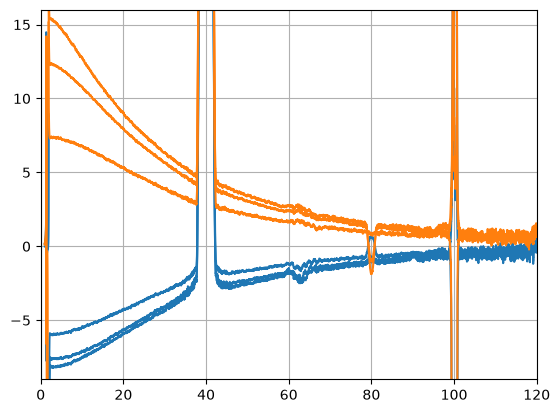

In [22]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

Let's now try to fit the model outlined at the top of this notebook to the measured data. Here, I've used `least_squares` from `scipy.optimize`, but `curve_fit` is a more common choice. An improved curve fitting tool is in the [LMFIT](https://lmfit.github.io/lmfit-py/) package.

First I define a function that takes as arguments the fitting parameters in a list (here $x$, $\eta$ and $f_{HWHM}$), the independent variable (here $f$), and the y-variable data (here the spectrum), and outputs the residuals between data and model. Then I test the fitting using the most anti-squeezed spectrum, using initial guesses of the parameters.

In [23]:
def res_asq(params, freq, spec):
    x, eta, bw = params
    model = lin2db(Vasq(x, eta, freq/bw))
    residuals = spec - model
    return residuals
    

In [25]:
num = db2lin(antisqueezing[2]) - db2lin(electronic)   # 분자
den = vacuum_corr_lin                                  # 분모

print('분자 음수 개수:', (num <= 0).sum())
print('분모 음수 개수:', (den <= 0).sum())

bad = np.isnan(test_spec)
print('NaN 개수:', bad.sum(), '/', len(test_spec))
print('NaN 나는 주파수(MHz):', f[bad])

분자 음수 개수: 5
분모 음수 개수: 61
NaN 개수: 56 / 5000
NaN 나는 주파수(MHz): [  1.47609522   1.49989998   1.52370474   1.5475095    1.57131426
   1.59511902   1.61892378   1.64272855   1.66653331   1.69033807
   1.71414283   1.73794759   1.76175235   1.78555711   1.80936187
   1.83316663   1.85697139  99.74214843  99.78975795  99.81356271
  99.83736747  99.86117223  99.884977    99.90878176  99.93258652
  99.95639128  99.98019604 100.0040008  100.02780556 100.05161032
 100.07541508 100.09921984 100.1230246  100.14682937 100.17063413
 100.19443889 100.21824365 100.24204841 100.26585317 100.28965793
 100.31346269 100.33726745 100.36107221 100.38487698 100.40868174
 100.4324865  100.45629126 100.48009602 100.50390078 100.52770554
 100.5515103  100.57531506 100.59911982 100.62292458 100.64672935
 100.67053411]


[  1.35707141   1.38087618   1.40468094   1.4284857    1.45229046
   1.47609522   1.49989998   1.52370474   1.5475095    1.57131426
   1.59511902   1.61892378   1.64272855   1.66653331   1.69033807
   1.71414283   1.73794759   1.76175235   1.78555711   1.80936187
   1.83316663   1.85697139  99.74214843  99.78975795  99.81356271
  99.83736747  99.86117223  99.884977    99.90878176  99.93258652
  99.95639128  99.98019604 100.0040008  100.02780556 100.05161032
 100.07541508 100.09921984 100.1230246  100.14682937 100.17063413
 100.19443889 100.21824365 100.24204841 100.26585317 100.28965793
 100.31346269 100.33726745 100.36107221 100.38487698 100.40868174
 100.4324865  100.45629126 100.48009602 100.50390078 100.52770554
 100.5515103  100.57531506 100.59911982 100.62292458 100.64672935
 100.67053411]


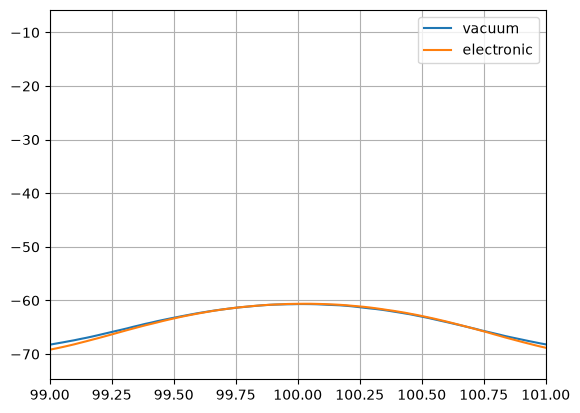

In [26]:
bad_den = db2lin(vacuum) - db2lin(electronic) <= 0
print(f[bad_den])
plt.plot(f, vacuum, label='vacuum')
plt.plot(f, electronic, label='electronic')
plt.xlim(99, 101); plt.legend(); plt.grid()

In [27]:
mask2 = ((f>2) & (f<35)) | ((f>45) & (f<75)) | ((f>85) & (f<95))

In [24]:
test_spec = antisqueezing_norm[2]
least_squares(res_asq, [.5,.8,40], args=[f, test_spec])

ValueError: Residuals are not finite in the initial point.

The error is due to the spectrum containing NaN values. These can be removed by masking them out, after which the fit works:

In [32]:
np.sum(res_asq([.5,.8,40], f, test_spec)**2)

np.float64(nan)

In [35]:
mask1 = ~np.isnan(test_spec)
res = least_squares(res_asq, [.5,.8,20], args=[f[mask1], test_spec[mask1]])
res

/tmp/ipykernel_33836/2130157308.py:2: RuntimeWarning: invalid value encountered in log10
  return 10 * np.log10(lin)


     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-1.378e+01 -1.376e+01 ... -7.074e-01 -5.132e-01]
           x: [ 2.493e-01  1.329e+01  2.412e+01]
        cost: 140515.82808358394
         jac: [[-2.777e+01 -3.133e-01 -1.050e-03]
               [-2.777e+01 -3.133e-01 -1.101e-03]
               ...
               [-6.077e+00 -1.123e-01 -1.211e-01]
               [-6.075e+00 -1.123e-01 -1.210e-01]]
        grad: [-5.112e+00 -9.117e-02 -9.270e-02]
  optimality: 5.111761878035395
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 17
        njev: 12

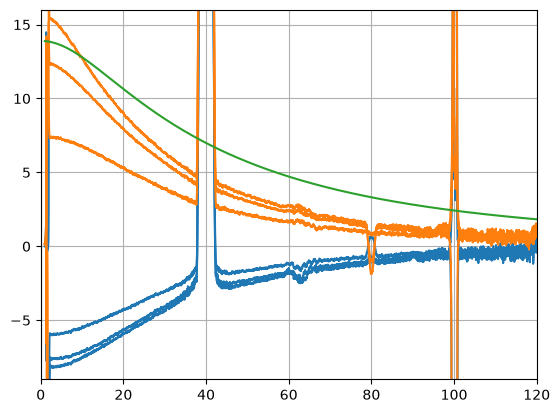

In [36]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

x_fit, eta_fit, bw_fit = res.x
plt.plot(f, lin2db(Vasq(x_fit, eta_fit, f/bw_fit)), 'C2')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

The fit is still very bad, as can be seen visually from the poor fit between data and model (green) and from the very large cost value of the fitting result. The poor fit is due to the strong signals around 40 MHz and 100 MHz and the overtone of the 40 MHz signal at 80 MHz. There's also some nasty stuff at very low frequencies. I therefore create a new mask that removes these frequencies from the data that goes into the fit:

In [37]:
mask2 = ((f>2) & (f<35)) | ((f>45) & (f<75)) | ((f>85) & (f<95))
mask = mask1 & mask2
len(np.nonzero(mask1 & mask2)[0])

3066

In [44]:
res = least_squares(res_asq, [.5,.8,20], args=[f[mask], test_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 3.661e-01  1.155e-01 ... -3.687e-01 -4.025e-01]
           x: [ 6.155e-01  2.275e+00  2.390e+01]
        cost: 34.81870230148614
         jac: [[-2.783e+01 -1.857e+00 -1.636e-02]
               [-2.781e+01 -1.857e+00 -1.672e-02]
               ...
               [-1.890e+00 -4.965e-01 -9.366e-02]
               [-1.889e+00 -4.963e-01 -9.363e-02]]
        grad: [-4.755e-02 -7.229e-03 -1.041e-03]
  optimality: 0.04754722264526001
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 21
        njev: 12

/tmp/ipykernel_33836/2130157308.py:2: RuntimeWarning: invalid value encountered in log10
  return 10 * np.log10(lin)


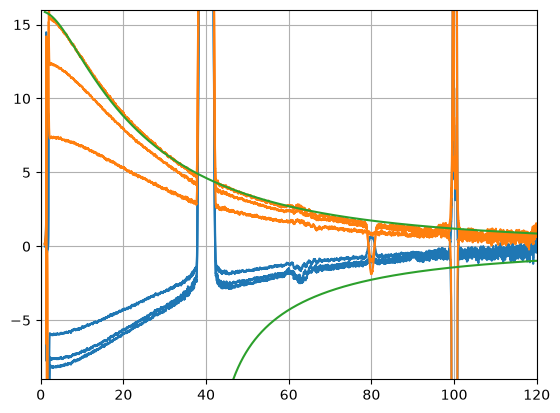

In [45]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

x_fit, eta_fit, bw_fit = res.x
plt.plot(f, lin2db(Vasq(x_fit, eta_fit, f/bw_fit)), 'C2')
plt.plot(f, lin2db(Vsq(x_fit, eta_fit, f/bw_fit)), 'C2')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

This was a really nice fit! The fitted parameters are in the `x` variable of the fitting result: `[ 7.463e-01  8.170e-01  3.622e+01]`, that is, $x=0.746$, $\eta=0.817$, $f_{HWHM}=36.2\text{ MHz}$.

Could we perhaps make it even better by using the more complex model with phase and phase fluctuation parameters? When adding more parameters, the optimisation problem becomes more ill-defined and "loose", so I will add some bounds to the parameters to help it along.

In [46]:
def res_asq2(params, freq, spec):
    x, eta, bw, theta, sigma = params
    model = lin2db(Vrotfluct(x, eta, freq/bw, theta, sigma))
    residuals = spec - model
    return residuals

In [47]:
res = least_squares(res_asq2, [.5,.8,40, 90, 0], bounds=([0,.5,10,80,0], [.99,1,50,100,10]), args=[f[mask], test_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 3.863e-01  1.357e-01 ... -3.547e-01 -3.885e-01]
           x: [ 7.266e-01  1.000e+00  3.387e+01  1.000e+02  1.000e-10]
        cost: 30.43938230843582
         jac: [[-3.535e+01 -4.225e+00 ...  2.671e-02  0.000e+00]
               [-3.531e+01 -4.225e+00 ...  2.671e-02  0.000e+00]
               ...
               [-1.628e+00 -1.119e+00 ...  1.221e-02  0.000e+00]
               [-1.627e+00 -1.119e+00 ...  1.221e-02  0.000e+00]]
        grad: [-2.000e-02 -1.035e+00 -6.098e-03 -8.466e-01  0.000e+00]
  optimality: 0.09833481065828523
 active_mask: [ 0  1  0  1 -1]
        nfev: 48
        njev: 41

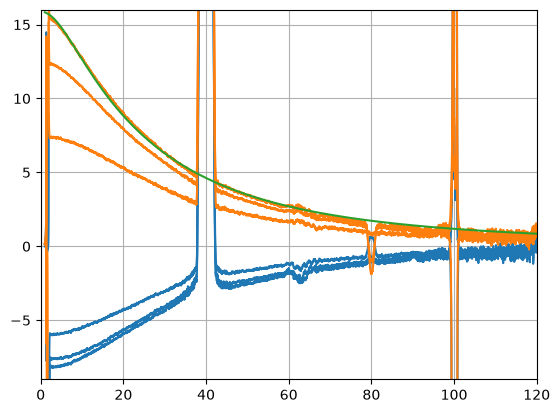

In [48]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

x_fit, eta_fit, bw_fit, theta_fit, sigma_fit = res.x
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, theta_fit, sigma_fit)), 'C2')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

This doesn't work very well. The fit looks OK'ish, but two of the parameters (`eta` and `theta`) are hitting their bounds which is a clear indication of a bad fit. Seems to be too many parameters.

Next, I try to fit both the antisqueezing and squeezing for a given power at the same time. Since they're recorded with the same power and same experimental setup, the parameters $x$, $\eta$ and $f_{HWHM}$ should be identical. I also assume $\sigma$ to be identical (not necessarily a good assumption). To fit both curves simultaneously, one can simply concatenate values for both spectra and for both models:

In [49]:
asq_spec = antisqueezing_norm[2]
sq_spec = squeezing_norm[2]

def res_asq3(params, freq, sq_spec, asq_spec):
    x, eta, bw, theta_sq, theta_asq, sigma = params
    sq_model = lin2db(Vrotfluct(x, eta, freq/bw, theta_sq, sigma))
    asq_model = lin2db(Vrotfluct(x, eta, freq/bw, theta_asq, sigma))
    model = np.concatenate([sq_model, asq_model])
    spec = np.concatenate([sq_spec, asq_spec])
    residuals = spec - model
    return residuals

In [50]:
res = least_squares(res_asq3, [.5,.8,40, 0, 90, 0], 
                    bounds=([0,.5,10,-10,80,0], [.99,1,50,10,100,10]), 
                    args=[f[mask], sq_spec[mask], sq_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-1.712e+01 -1.234e+01 ... -8.686e-01 -8.827e-01]
           x: [ 1.341e-02  1.000e+00  3.543e+01  1.314e-20  8.000e+01
                1.000e-10]
        cost: 60987.58282666783
         jac: [[ 1.732e+01  2.385e-01 ...  0.000e+00  0.000e+00]
               [ 1.732e+01  2.385e-01 ...  0.000e+00  0.000e+00]
               ...
               [-1.996e+00 -2.667e-02 ... -3.377e-04  0.000e+00]
               [-1.995e+00 -2.666e-02 ... -3.375e-04  0.000e+00]]
        grad: [-1.006e+00 -7.516e+01  1.607e-02  0.000e+00  2.109e+01
                0.000e+00]
  optimality: 0.9828908824170731
 active_mask: [ 0  0  0  0  0 -1]
        nfev: 17
        njev: 15

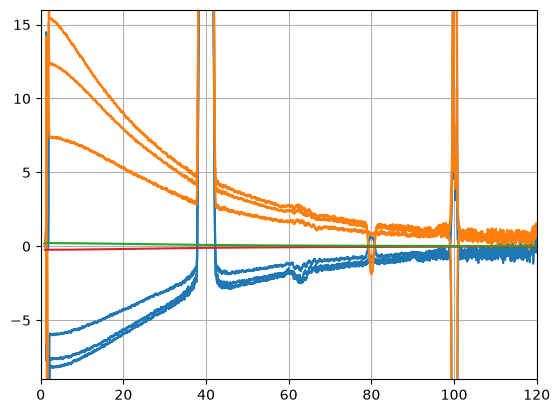

In [51]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

x_fit, eta_fit, bw_fit, theta_sq_fit, theta_asq_fit, sigma_fit = res.x
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, theta_sq_fit, sigma_fit)), 'C3')
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, theta_asq_fit, sigma_fit)), 'C2')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

That was a very poor fit! Let's try to remove the phase parameters and go back to basics:

In [52]:
asq_spec = antisqueezing_norm[2]  # change index here to switch between the spectra taken at three different powers
sq_spec = squeezing_norm[2]

def res_asq3(params, freq, sq_spec, asq_spec):
    x, eta, bw = params
    sq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    asq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    model = np.concatenate([sq_model, asq_model])
    spec = np.concatenate([sq_spec, asq_spec])
    residuals = spec - model
    return residuals

In [53]:
res = least_squares(res_asq3, [.5,.8,40], 
                    bounds=([0,.5,10], [.99,1,50]), 
                    args=[f[mask], sq_spec[mask], sq_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.988e+00 -4.205e+00 ...  8.024e-02  6.581e-02]
           x: [ 6.829e-01  8.872e-01  3.028e+01]
        cost: 173.9229214030086
         jac: [[ 7.079e+00  2.872e+01  2.651e-03]
               [ 7.078e+00  2.871e+01  2.713e-03]
               ...
               [ 1.231e+00  1.158e+00  5.269e-02]
               [ 1.231e+00  1.157e+00  5.267e-02]]
        grad: [ 1.045e-04 -6.766e-04  1.507e-05]
  optimality: 0.00030562734484347576
 active_mask: [0 0 0]
        nfev: 6
        njev: 6

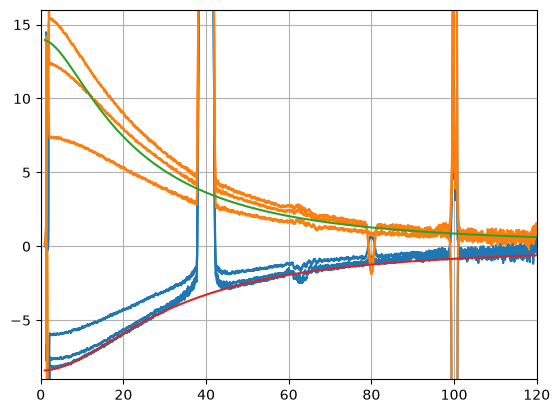

In [54]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

x_fit, eta_fit, bw_fit = res.x
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 0, 0)), 'C3')
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 90, 0)), 'C2')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

The fit works much better now with fewer parameters. Still, for some reason, the dual fit doesn't fit well for the highest-power traces. I suspect there might be an issue with the data, or the model fails to take into account some property of the experiment. The fit for the lowest-power spectra also doesn't look amazing:

In [55]:
asq_spec = antisqueezing_norm[0]
sq_spec = squeezing_norm[0]

def res_asq3(params, freq, sq_spec, asq_spec):
    x, eta, bw = params
    sq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    asq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    model = np.concatenate([sq_model, asq_model])
    spec = np.concatenate([sq_spec, asq_spec])
    residuals = spec - model
    return residuals

In [56]:
res = least_squares(res_asq3, [.5,.8,40], 
                    bounds=([0,.5,10], [.99,1,50]), 
                    args=[f[mask], sq_spec[mask], sq_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-3.093e+00 -1.813e+00 ...  1.342e-01  1.071e-01]
           x: [ 4.870e-01  8.612e-01  2.833e+01]
        cost: 48.29788710252677
         jac: [[ 9.621e+00  1.571e+01  2.197e-03]
               [ 9.620e+00  1.570e+01  2.248e-03]
               ...
               [ 1.135e+00  7.192e-01  3.652e-02]
               [ 1.134e+00  7.188e-01  3.651e-02]]
        grad: [-7.643e-04 -2.650e-03  4.493e-05]
  optimality: 0.0008238443856218221
 active_mask: [0 0 0]
        nfev: 6
        njev: 6

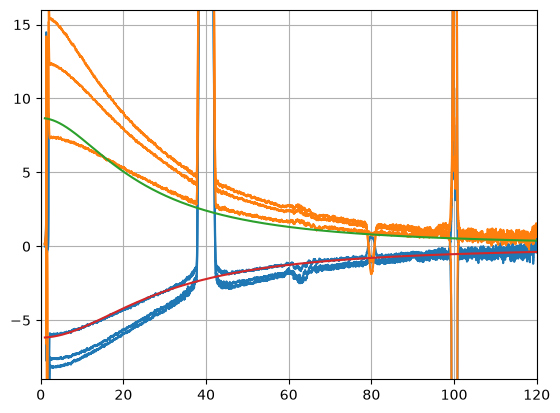

In [57]:
for sq in squeezing_norm:
    plt.plot(f, sq, c='C0')
for asq in antisqueezing_norm:
    plt.plot(f, asq, c='C1')

x_fit, eta_fit, bw_fit = res.x
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 0, 0)), 'C3')
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 90, 0)), 'C2')

plt.ylim(-9,16)
plt.xlim(0, 120)
plt.grid()

However, another issue might be that measurements are a bit unreliable at higher frequencies where the detector efficiency is low (as seen in the first raw spectrum at the top). These have a relatively large weight in the fit and seem to skew the fit in a way that the more accurate low-frequency values don't fit well. 

To test this, below I made a "manual fitting machine" using widgets for the parameters. The default parameters inserted here work quite well for the lowest power spectra -- both squeezing and anti-squeezing -- at low frequencies, while especially the squeezing is somewhat off at higher frequencies. But this looks already much better. When increasing `x` it also somewhat matches the middle-power anti-squeezing and the highest-power squeezing - not what one would expect. It could be that the power labels in the file names are not correct, or (perhaps more likely) that the detector has some saturation at high noise powers.

This manual fitting shows that there is still some massaging to do to make the optimiser give a more realistic fit.

In [ ]:
from ipywidgets import interact

@interact(x=(0.,.999,.01), eta=(0.,1.,.01), bw=(10.,100.,1.), 
          theta_sq_offset=(-45.,45.,.1), theta_asq_offset=(-45.,45.,.1), sigma=(0.,10.,.01))
def manual_fit(x=.43, eta=.9, bw=33., theta_sq_offset=0., theta_asq_offset=0., sigma=0.):

    for sq in squeezing_norm:
        plt.plot(f, sq, c='C0')
    for asq in antisqueezing_norm:
        plt.plot(f, asq, c='C1')
    
    plt.plot(f, lin2db(Vrotfluct(x, eta, f/bw, 90+theta_asq_offset, sigma)), 'C2')
    plt.plot(f, lin2db(Vrotfluct(x, eta, f/bw, 0+theta_sq_offset, sigma)), 'C2')
    
    plt.ylim(-9,16)
    plt.xlim(0, 120)
    plt.grid()

interactive(children=(FloatSlider(value=0.43, description='x', max=0.999, step=0.01), FloatSlider(value=0.9, d…

### Save to HDF5

It is a very good idea to store data in the HDF5 format. It can contain multiple datasets, metadata, attributes on each dataset, and it is quite fast to look into even GB-large files using some of the available HDF5 viewers or e.g. the H5Web extension to VS Code. Here we format the metadata from one of the traces (using `dtype='S'` as the default `'U'` datatype for NumPy string arrays does not work) and place it in a single .hdf5 file together with all the spectra extracted from the CSV files.

In [59]:
meta_elec = np.genfromtxt(elec_spec_file, delimiter=',', skip_header=2, max_rows=42, dtype='S')
meta_elec

array([[b'A.18.12', b'N9000A'],
       [b'503 ', b'01'],
       [b'Segment', b'0'],
       [b'Number of Points', b'5000'],
       [b'Sweep Time', b'0.889488733333'],
       [b'Start Frequency', b'1000000'],
       [b'Stop Frequency', b'120000000'],
       [b'Average Count', b'0'],
       [b'Average Type', b'LogPower(Video)'],
       [b'RBW', b'1100000'],
       [b'RBW Filter', b'Gaussian'],
       [b'RBW Filter BW', b'3dB'],
       [b'VBW', b'300'],
       [b'Sweep Type', b'Swept'],
       [b'X Axis Scale', b'Lin'],
       [b'PreAmp State', b'Off'],
       [b'PreAmp Band', b'Low'],
       [b'Trigger Source', b'Free'],
       [b'Trigger Level', b'1.2'],
       [b'Trigger Slope', b'Positive'],
       [b'Trigger Delay', b'0'],
       [b'Phase Noise Optimization', b'Fast'],
       [b'Swept If Gain', b'Low'],
       [b'FFT If Gain', b'Autorange'],
       [b'RF Coupling', b'AC'],
       [b'FFT Width', b'411900'],
       [b'Ext Ref', b'10000000'],
       [b'Input', b'RF'],
       [b'RF Calibr

In [60]:
meta_elec = {a[0]:a[1] for a in meta_elec}
meta_elec

{np.bytes_(b'A.18.12'): np.bytes_(b'N9000A'),
 np.bytes_(b'503 '): np.bytes_(b'01'),
 np.bytes_(b'Segment'): np.bytes_(b'0'),
 np.bytes_(b'Number of Points'): np.bytes_(b'5000'),
 np.bytes_(b'Sweep Time'): np.bytes_(b'0.889488733333'),
 np.bytes_(b'Start Frequency'): np.bytes_(b'1000000'),
 np.bytes_(b'Stop Frequency'): np.bytes_(b'120000000'),
 np.bytes_(b'Average Count'): np.bytes_(b'0'),
 np.bytes_(b'Average Type'): np.bytes_(b'LogPower(Video)'),
 np.bytes_(b'RBW'): np.bytes_(b'1100000'),
 np.bytes_(b'RBW Filter'): np.bytes_(b'Gaussian'),
 np.bytes_(b'RBW Filter BW'): np.bytes_(b'3dB'),
 np.bytes_(b'VBW'): np.bytes_(b'300'),
 np.bytes_(b'Sweep Type'): np.bytes_(b'Swept'),
 np.bytes_(b'X Axis Scale'): np.bytes_(b'Lin'),
 np.bytes_(b'PreAmp State'): np.bytes_(b'Off'),
 np.bytes_(b'PreAmp Band'): np.bytes_(b'Low'),
 np.bytes_(b'Trigger Source'): np.bytes_(b'Free'),
 np.bytes_(b'Trigger Level'): np.bytes_(b'1.2'),
 np.bytes_(b'Trigger Slope'): np.bytes_(b'Positive'),
 np.bytes_(b'Trigge

In [61]:
with h5py.File('squeezing_data.hdf5', 'w') as file:
    dset_spec = file.create_group('spectrum')
    dset_freq = dset_spec.create_dataset('frequencies', data=f)
    dset_elec = dset_spec.create_dataset('electronic', data=electronic)
    dset_vac = dset_spec.create_dataset('vacuum', data=vacuum)
    dset_sqz = dset_spec.create_dataset('squeezing', data=squeezing)
    dset_asqz = dset_spec.create_dataset('antisqueezing', data=antisqueezing)
    for key, val in meta_elec.items():
        dset_spec.attrs[key] = val

The data can also be compressed:

In [62]:
with h5py.File('squeezing_data_zipped.hdf5', 'w') as file:
    dset_spec = file.create_group('spectrum')
    dset_freq = dset_spec.create_dataset('frequencies', data=f, chunks=True, compression='gzip')
    dset_elec = dset_spec.create_dataset('electronic', data=electronic, chunks=True, compression='gzip')
    dset_vac = dset_spec.create_dataset('vacuum', data=vacuum, chunks=True, compression='gzip')
    dset_sqz = dset_spec.create_dataset('squeezing', data=squeezing, chunks=True, compression='gzip')
    dset_asqz = dset_spec.create_dataset('antisqueezing', data=antisqueezing, chunks=True, compression='gzip')
    for key, val in meta_elec.items():
        dset_spec.attrs[key] = val

Reading HDF5 files is also easy - just access it like a file system:

In [63]:
file = h5py.File('squeezing_data_zipped.hdf5', 'r')
list(file.keys())

['spectrum']

In [64]:
list(file['spectrum'].keys())

['antisqueezing', 'electronic', 'frequencies', 'squeezing', 'vacuum']

In [65]:
spec = file['spectrum']
spec['frequencies'][:]

array([  1.        ,   1.02380476,   1.04760952, ..., 119.95239048,
       119.97619524, 120.        ], shape=(5000,))

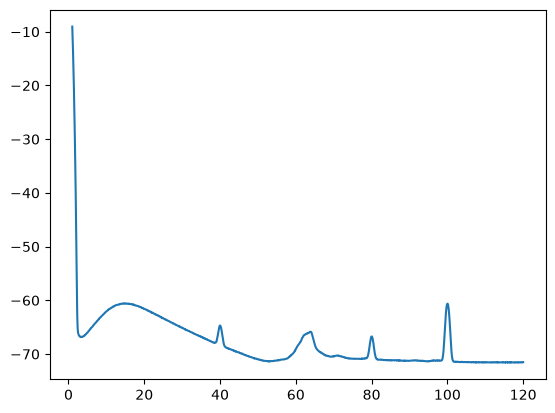

In [66]:
spec = file['spectrum']
plt.plot(spec['frequencies'][:], spec['electronic'][:])
file.close()

If you have the H5web VS Code extension installed, you can also view the data directly from the hdf5 file:

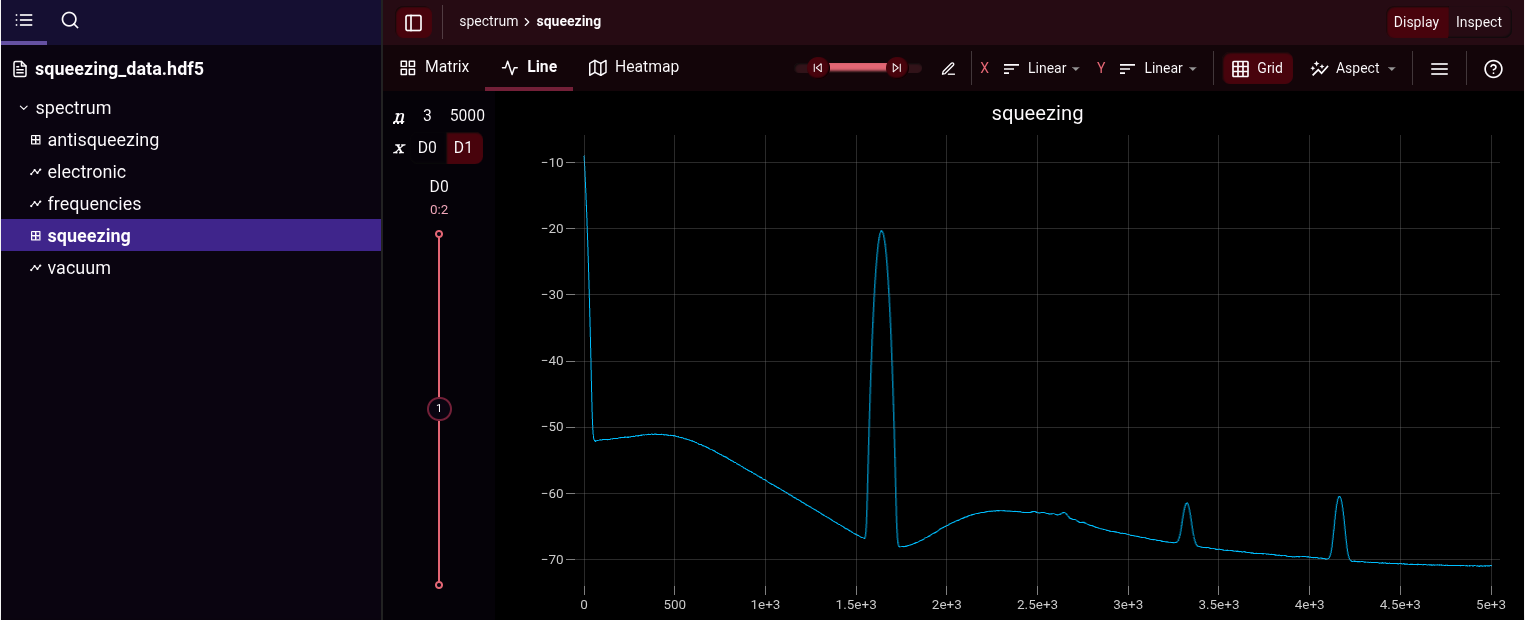

## Xueshi data

Below I give just the minimum necessary code to load Xueshi's data files. Then it's your turn to play around with it.

LeCroy oscilloscopes use the proprietary binary file format is described on pages 190—192 of [this reference document](https://cdn.teledynelecroy.com/files/manuals/maui-remote-control-and-automation-manual.pdf). A handful of people have made their own small packages to read this file format (try to search for 'lecroy' on Github) – [including me](https://github.com/neago/lecroy-reader). You should be able to install this into your environment by 
```
uv add git+ssh://git@github.com/neago/lecroy-reader.git
```
for SSH authentication or
```
uv add git+https://github.com/neago/lecroy-reader.git
```
for HTTPS.

In [ ]:
datasets = ['electronic', 'shotnoise', 'squeezing', 'antisqueezing']
channels = ['C1', 'C2', 'C3', 'C4']

def get_file_list(dataset, channel):
    folder = os.path.join(xueshi_folder, dataset, channel)
    fns = sorted(os.listdir(folder))
    fns = [os.path.join(folder, fn) for fn in fns]
    return fns

files = {ds:
           {ch:get_file_list(ds, ch) for ch in channels}
           for ds in datasets}

In [ ]:
meta, times, data = lecroy.read(files['shotnoise']['C1'][0], scale=False)
dt = meta['horiz_interval']
fs = 1/dt
N = len(data[0])
t = np.linspace(0, dt*N, N, endpoint=False)
f = rfftfreq(N, dt)
# meta

In [ ]:
meta

In [ ]:
for ds in datasets:
    data = np.array([[
        lecroy.read(f, scale=False)[2] for f in files[ds][ch]]
                     for ch in channels])
    data = data.squeeze()  # not optical squeezing!
    globals()[ds] = data


In [ ]:
electronic.shape, shotnoise.shape, squeezing.shape, antisqueezing.shape

In [ ]:
plt.plot(t, antisqueezing[0,0])

In [ ]:
fig, axs = plt.subplots(1, 2)
spec = np.fft.rfft(antisqueezing[0,0])
psd = 10*np.log10(np.abs(spec)**2)
axs[0].plot(f, psd)
axs[1].plot(f, psd)
axs[1].set_xlim(0, 50e6)

In [ ]:
peaks = sp.signal.find_peaks(psd, height=125, threshold=5, distance=1000)
peaks

In [ ]:
f[peaks[0]] / 1e6